# ORACLE — PLABA EDA
## Plain Language Adaptation Domain

**Dataset:** PLABA — 921 plain language adaptation instances (Attal et al., 2023)
**Source:** OSF Repository — osf.io/rnpmf | 75 health topics, 750 PubMed abstracts
**Key finding:** Compression ratio ~1.0 — plain language = full-length rewrite, not summary
**Purpose:** ORACLE gold standard plain language generation evaluation benchmark

In [1]:
import sys, os, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plaba_loader import load_plaba_all

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)
TYPE_COLORS = {'C': 'steelblue', 'B': 'coral'}
SPLIT_COLORS = {'train': '#2ecc71', 'val': '#f39c12', 'test': '#e74c3c'}
print('Imports complete')

Imports complete


In [2]:
result = load_plaba_all()
frames = []
for split in ['train', 'val', 'test']:
    df_split = result[split]['data'].copy()
    df_split['target_text'] = result[split]['labels'].values
    df_split['split'] = split
    frames.append(df_split)
df = pd.concat(frames, ignore_index=True)

df['input_len'] = df['input_text'].astype(str).str.len()
df['target_len'] = df['target_text'].astype(str).str.len()
df['input_words'] = df['input_text'].astype(str).str.split().str.len()
df['target_words'] = df['target_text'].astype(str).str.split().str.len()
df['compression_ratio'] = df['target_len'] / df['input_len']
df['word_ratio'] = df['target_words'] / df['input_words']

print(f'Shape: {df.shape}')
print(f'Total records: {len(df):,}')
print(f'Unique topics: {df["question"].nunique()}')
print(f'Unique PMIDs: {df["pmid"].nunique():,}')

Loading PLABA — all splits...
Loading PLABA train split...


  Records:  635
  Topics:   53 health topics
Loading PLABA val split...


  Records:  138
  Topics:   11 health topics
Loading PLABA test split...


  Records:  148
  Topics:   11 health topics

PLABA loaded: 921 total instances
  Note: 750 unique abstracts across 75 topics — 921 rows due to multiple adaptation versions
Shape: (921, 12)
Total records: 921
Unique topics: 75
Unique PMIDs: 750


## 1. Split Distribution — Train/Val/Test

Train=635 (68.9%), Val=138 (15.0%), Test=148 (16.1%). Standard 70/15/15 split.

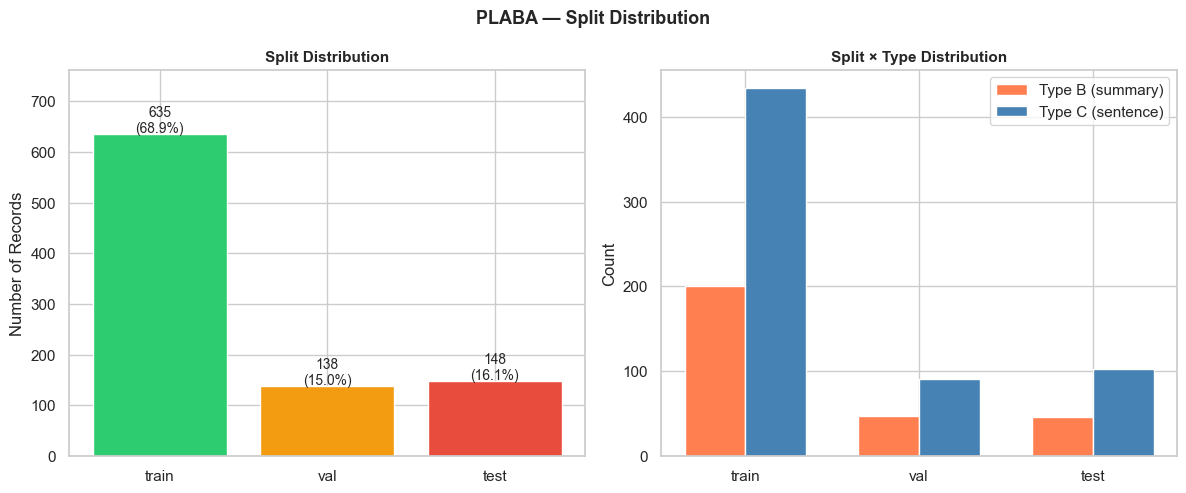

Fig 1 saved — plaba_split_distribution.png


In [3]:
split_counts = df['split'].value_counts().reindex(['train','val','test'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(split_counts.index, split_counts.values,
                   color=[SPLIT_COLORS[s] for s in split_counts.index], edgecolor='white')
for bar, val in zip(bars, split_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)
axes[0].set_title('Split Distribution', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Records'); axes[0].set_ylim(0, split_counts.max()*1.2)

split_type = df.groupby(['split','Question_Type']).size().unstack().reindex(['train','val','test'])
x = np.arange(3); width = 0.35
axes[1].bar(x-width/2, split_type['B'], width, color='coral', label='Type B (summary)', edgecolor='white')
axes[1].bar(x+width/2, split_type['C'], width, color='steelblue', label='Type C (sentence)', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(['train','val','test'])
axes[1].set_title('Split × Type Distribution', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count'); axes[1].legend()

plt.suptitle('PLABA — Split Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/plaba_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 1 saved — plaba_split_distribution.png')

## 2. Question Type Distribution — Type C Dominates (68.1%)

Type C (sentence-level): 627 (68.1%) — preserves structure, simplifies vocabulary.
Type B (summary-level): 294 (31.9%) — restructures and reorganizes content.

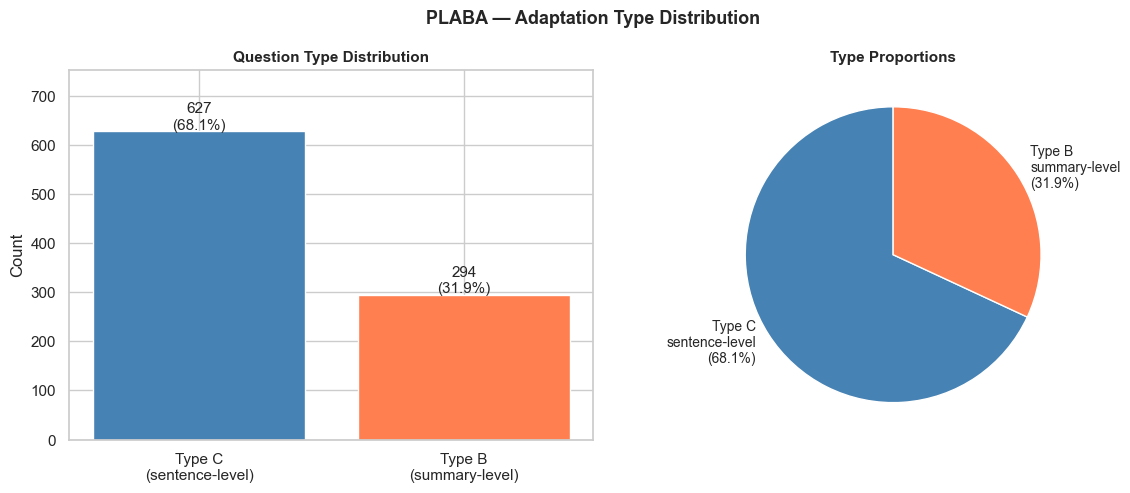

Fig 2 saved — plaba_type_distribution.png


In [4]:
qt_counts = df['Question_Type'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(['Type C\n(sentence-level)', 'Type B\n(summary-level)'],
                   [qt_counts.get('C',0), qt_counts.get('B',0)],
                   color=['steelblue','coral'], edgecolor='white')
for bar, val in zip(bars, [qt_counts.get('C',0), qt_counts.get('B',0)]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=11)
axes[0].set_title('Question Type Distribution', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].set_ylim(0, qt_counts.max()*1.2)

axes[1].pie([qt_counts.get('C',0), qt_counts.get('B',0)],
            labels=['Type C\nsentence-level\n(68.1%)', 'Type B\nsummary-level\n(31.9%)'],
            colors=['steelblue','coral'], startangle=90, textprops={'fontsize':10})
axes[1].set_title('Type Proportions', fontsize=11, fontweight='bold')

plt.suptitle('PLABA — Adaptation Type Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/plaba_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 2 saved — plaba_type_distribution.png')

## 3. Input Text Length — Professional Biomedical Abstracts

Mean=1,574 chars (228 words). Consistent across Type B and C.

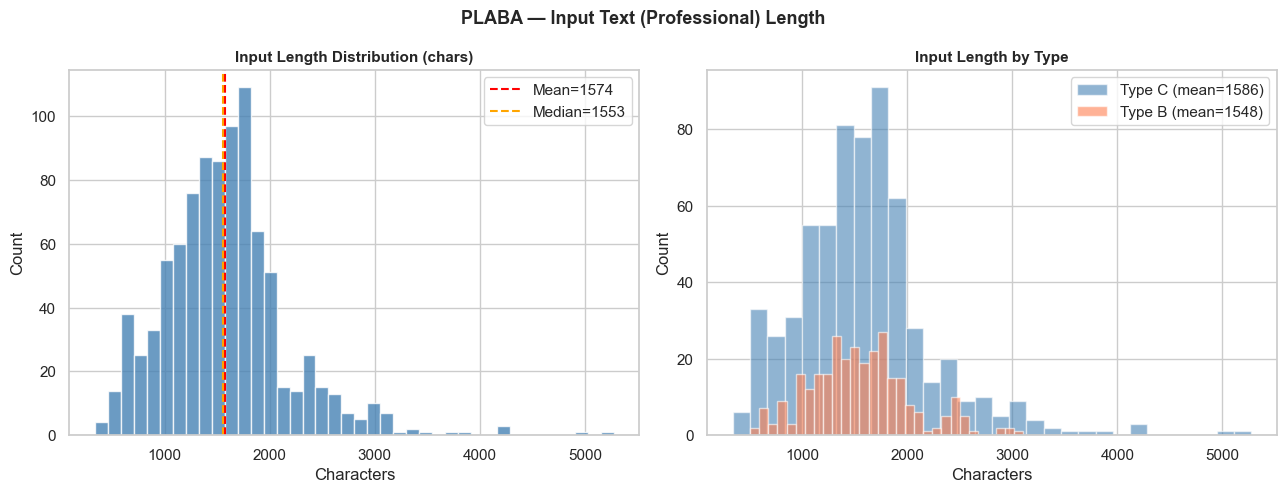

Fig 3 saved — plaba_input_length.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['input_len'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['input_len'].mean(), color='red', linestyle='--',
                label=f'Mean={df["input_len"].mean():.0f}')
axes[0].axvline(df['input_len'].median(), color='orange', linestyle='--',
                label=f'Median={df["input_len"].median():.0f}')
axes[0].set_title('Input Length Distribution (chars)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Characters'); axes[0].set_ylabel('Count'); axes[0].legend()

for qt, color in TYPE_COLORS.items():
    subset = df[df['Question_Type']==qt]['input_len']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color,
                 label=f'Type {qt} (mean={subset.mean():.0f})')
axes[1].set_title('Input Length by Type', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Characters'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.suptitle('PLABA — Input Text (Professional) Length', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/plaba_input_length.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 3 saved — plaba_input_length.png')

## 4. Target Text Length — Plain Language Adaptations

Mean=1,532 chars (238 words). Slightly shorter in chars but MORE words than input.

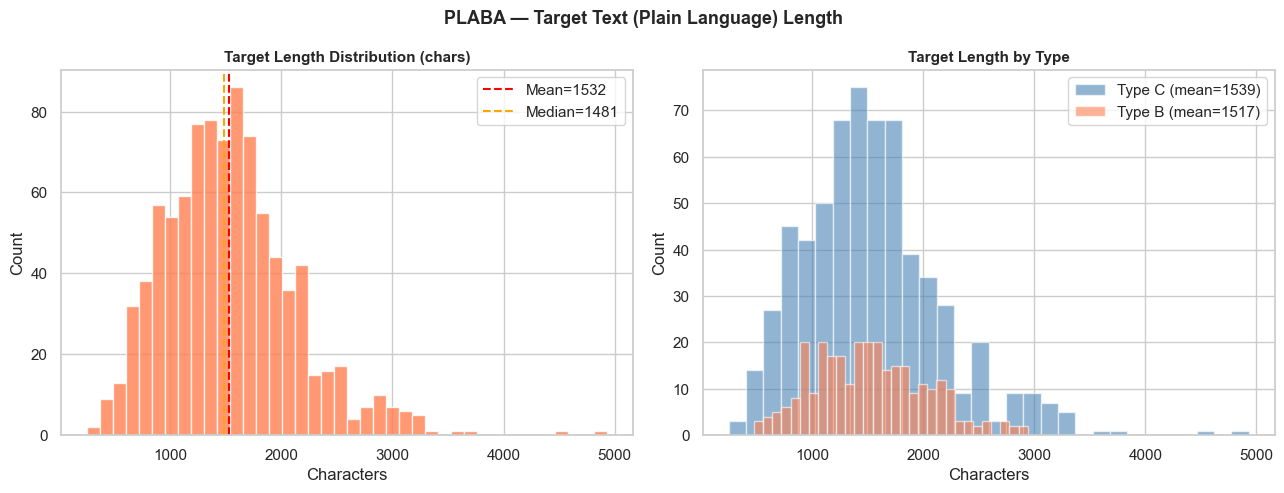

Fig 4 saved — plaba_target_length.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['target_len'], bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[0].axvline(df['target_len'].mean(), color='red', linestyle='--',
                label=f'Mean={df["target_len"].mean():.0f}')
axes[0].axvline(df['target_len'].median(), color='orange', linestyle='--',
                label=f'Median={df["target_len"].median():.0f}')
axes[0].set_title('Target Length Distribution (chars)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Characters'); axes[0].set_ylabel('Count'); axes[0].legend()

for qt, color in TYPE_COLORS.items():
    subset = df[df['Question_Type']==qt]['target_len']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color,
                 label=f'Type {qt} (mean={subset.mean():.0f})')
axes[1].set_title('Target Length by Type', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Characters'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.suptitle('PLABA — Target Text (Plain Language) Length', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/plaba_target_length.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 4 saved — plaba_target_length.png')

## 5. Input vs Target Length Comparison — Plain Language Is NOT Shorter

Professional mean=1,574 chars vs Plain language mean=1,532 chars — only 42 char difference.
53.4% adaptations are shorter, 46.5% are longer — nearly even split.

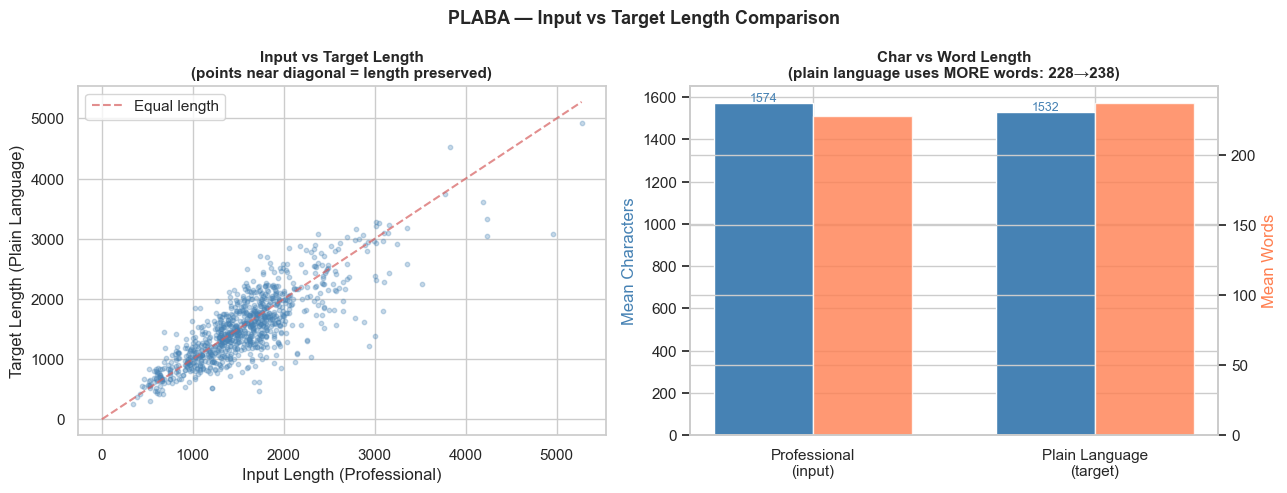

Fig 5 saved — plaba_length_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter plot
axes[0].scatter(df['input_len'], df['target_len'], alpha=0.3, color='steelblue', s=10)
max_len = max(df['input_len'].max(), df['target_len'].max())
axes[0].plot([0, max_len], [0, max_len], 'r--', alpha=0.7, label='Equal length')
axes[0].set_xlabel('Input Length (Professional)'); axes[0].set_ylabel('Target Length (Plain Language)')
axes[0].set_title('Input vs Target Length\n(points near diagonal = length preserved)', fontsize=11, fontweight='bold')
axes[0].legend()

# Bar comparison
categories = ['Professional\n(input)', 'Plain Language\n(target)']
char_means = [df['input_len'].mean(), df['target_len'].mean()]
word_means = [df['input_words'].mean(), df['target_words'].mean()]
x = np.arange(2); width = 0.35
axes[1].bar(x-width/2, char_means, width, color='steelblue', label='Mean chars/10', edgecolor='white',
            bottom=0)
ax2 = axes[1].twinx()
ax2.bar(x+width/2, word_means, width, color='coral', label='Mean words', edgecolor='white', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Mean Characters', color='steelblue')
ax2.set_ylabel('Mean Words', color='coral')
axes[1].set_title(f'Char vs Word Length\n(plain language uses MORE words: {df["input_words"].mean():.0f}→{df["target_words"].mean():.0f})', fontsize=11, fontweight='bold')
for bar, val in zip(axes[1].patches, char_means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f'{val:.0f}', ha='center', fontsize=9, color='steelblue')

plt.suptitle('PLABA — Input vs Target Length Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/plaba_length_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 5 saved — plaba_length_comparison.png')

## 6. Compression Ratio Distribution — Ratio ~1.0

Overall ratio=0.992 — plain language almost exactly same length as professional.
Word ratio=1.064 — MORE words in plain language (shorter words, more of them).

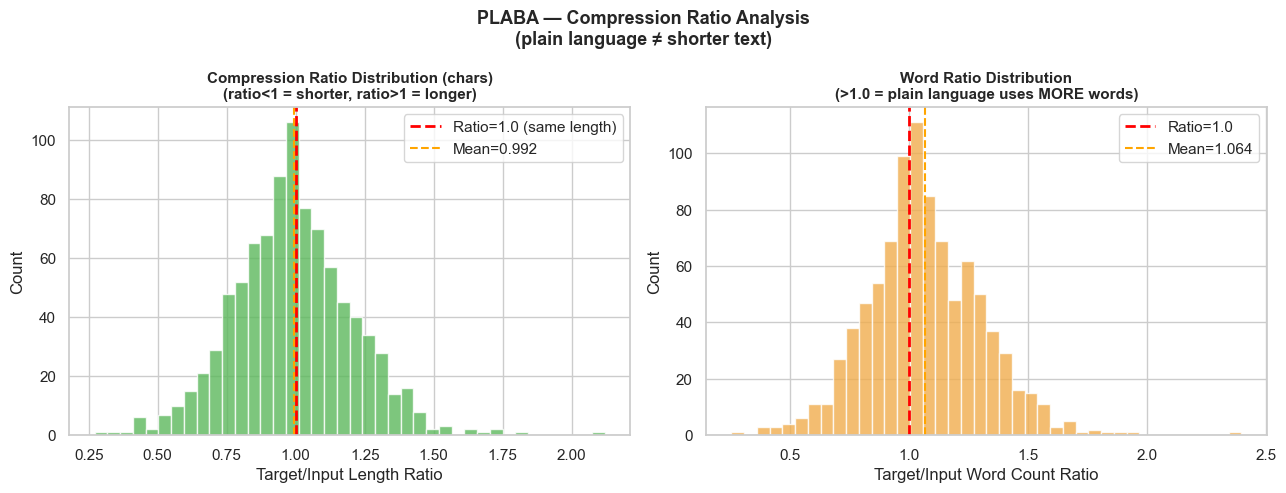

Fig 6 saved — plaba_compression_ratio.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['compression_ratio'], bins=40, color='#5cb85c', edgecolor='white', alpha=0.8)
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio=1.0 (same length)')
axes[0].axvline(df['compression_ratio'].mean(), color='orange', linestyle='--',
                label=f'Mean={df["compression_ratio"].mean():.3f}')
axes[0].set_title('Compression Ratio Distribution (chars)\n(ratio<1 = shorter, ratio>1 = longer)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Target/Input Length Ratio'); axes[0].set_ylabel('Count'); axes[0].legend()

axes[1].hist(df['word_ratio'], bins=40, color='#f0ad4e', edgecolor='white', alpha=0.8)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio=1.0')
axes[1].axvline(df['word_ratio'].mean(), color='orange', linestyle='--',
                label=f'Mean={df["word_ratio"].mean():.3f}')
axes[1].set_title('Word Ratio Distribution\n(>1.0 = plain language uses MORE words)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Target/Input Word Count Ratio'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.suptitle('PLABA — Compression Ratio Analysis\n(plain language ≠ shorter text)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/plaba_compression_ratio.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 6 saved — plaba_compression_ratio.png')

## 7. Compression Ratio by Type — Type B Slightly More Words

Both types have ratio ~1.0. Type B (summary) uses slightly more words than Type C (sentence).

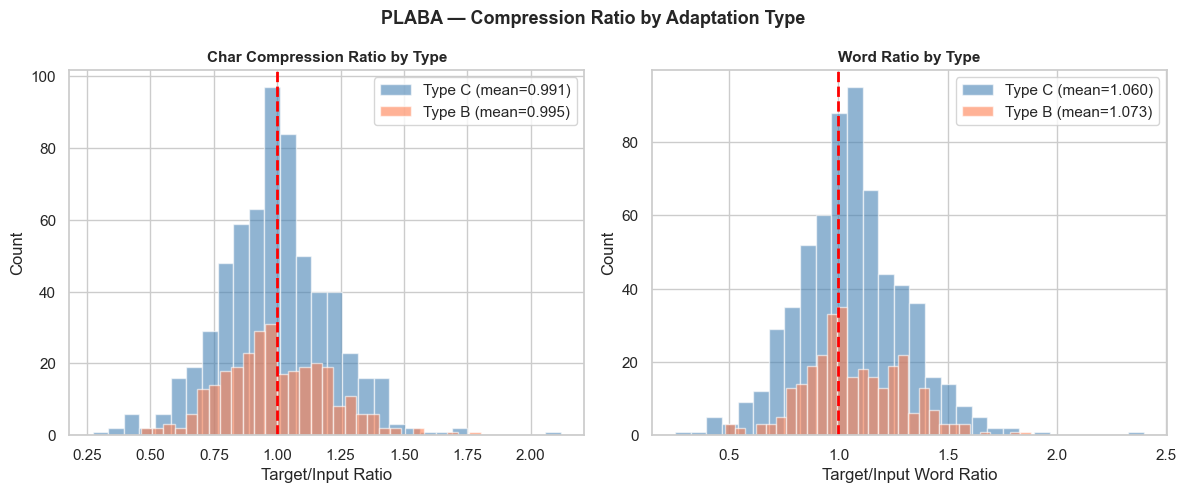

Fig 7 saved — plaba_ratio_by_type.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for qt, color in TYPE_COLORS.items():
    subset = df[df['Question_Type']==qt]
    axes[0].hist(subset['compression_ratio'], bins=30, alpha=0.6, color=color,
                 label=f'Type {qt} (mean={subset["compression_ratio"].mean():.3f})')
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Char Compression Ratio by Type', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Target/Input Ratio'); axes[0].set_ylabel('Count'); axes[0].legend()

for qt, color in TYPE_COLORS.items():
    subset = df[df['Question_Type']==qt]
    axes[1].hist(subset['word_ratio'], bins=30, alpha=0.6, color=color,
                 label=f'Type {qt} (mean={subset["word_ratio"].mean():.3f})')
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Word Ratio by Type', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Target/Input Word Ratio'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.suptitle('PLABA — Compression Ratio by Adaptation Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/plaba_ratio_by_type.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 7 saved — plaba_ratio_by_type.png')

## 8. Topics Distribution — 75 Health Topics, Mean 12.3 Records

Min=9, max=20 records per topic. Some topics have multiple adaptation versions per abstract.

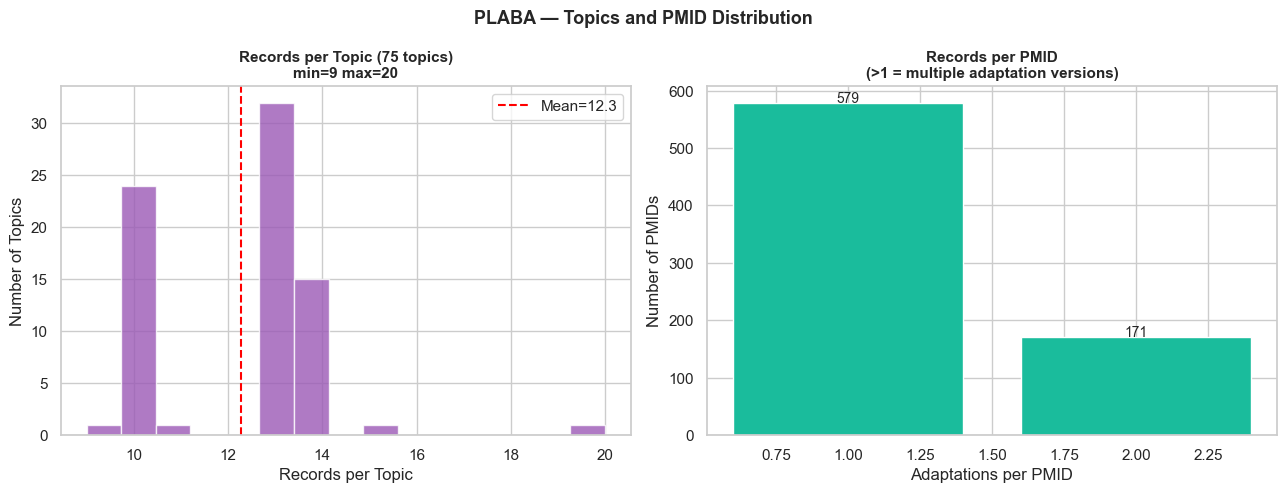

Fig 8 saved — plaba_topics_distribution.png


In [10]:
topic_counts = df.groupby('question').size().sort_values()
pmid_counts = df.groupby('pmid').size().value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(topic_counts.values, bins=15, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[0].axvline(topic_counts.mean(), color='red', linestyle='--',
                label=f'Mean={topic_counts.mean():.1f}')
axes[0].set_title(f'Records per Topic (75 topics)\nmin={topic_counts.min()} max={topic_counts.max()}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Records per Topic'); axes[0].set_ylabel('Number of Topics'); axes[0].legend()

bars = axes[1].bar(pmid_counts.index, pmid_counts.values, color='#1abc9c', edgecolor='white')
for bar, val in zip(bars, pmid_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:,}', ha='center', fontsize=10)
axes[1].set_title('Records per PMID\n(>1 = multiple adaptation versions)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Adaptations per PMID'); axes[1].set_ylabel('Number of PMIDs')

plt.suptitle('PLABA — Topics and PMID Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/plaba_topics_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 8 saved — plaba_topics_distribution.png')

## 9. Input vs Target Word Count — Plain Language Uses More Words

Input mean=228 words vs Target mean=238 words. Plain language uses shorter words in longer sentences.

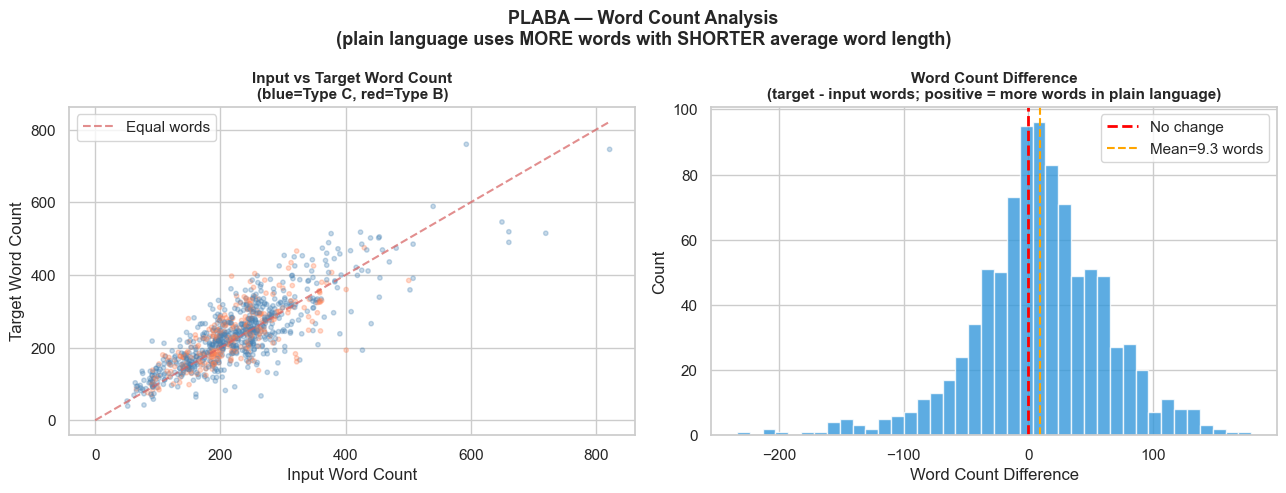

Fig 9 saved — plaba_word_count.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['input_words'], df['target_words'], alpha=0.3,
               c=df['Question_Type'].map({'C':'steelblue','B':'coral'}), s=10)
max_words = max(df['input_words'].max(), df['target_words'].max())
axes[0].plot([0, max_words], [0, max_words], 'r--', alpha=0.7, label='Equal words')
axes[0].set_xlabel('Input Word Count'); axes[0].set_ylabel('Target Word Count')
axes[0].set_title('Input vs Target Word Count\n(blue=Type C, red=Type B)', fontsize=11, fontweight='bold')
axes[0].legend()

word_diff = df['target_words'] - df['input_words']
axes[1].hist(word_diff, bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[1].axvline(word_diff.mean(), color='orange', linestyle='--',
                label=f'Mean={word_diff.mean():.1f} words')
axes[1].set_title('Word Count Difference\n(target - input words; positive = more words in plain language)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Word Count Difference'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.suptitle('PLABA — Word Count Analysis\n(plain language uses MORE words with SHORTER average word length)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/plaba_word_count.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 9 saved — plaba_word_count.png')

## 9b. Adaptation Direction — Near 50/50 Shorter vs Longer

Shorter: 53.4%, Longer: 46.5% — near even split by type.
Confirms no systematic compression — plain language rewrites, not condenses.

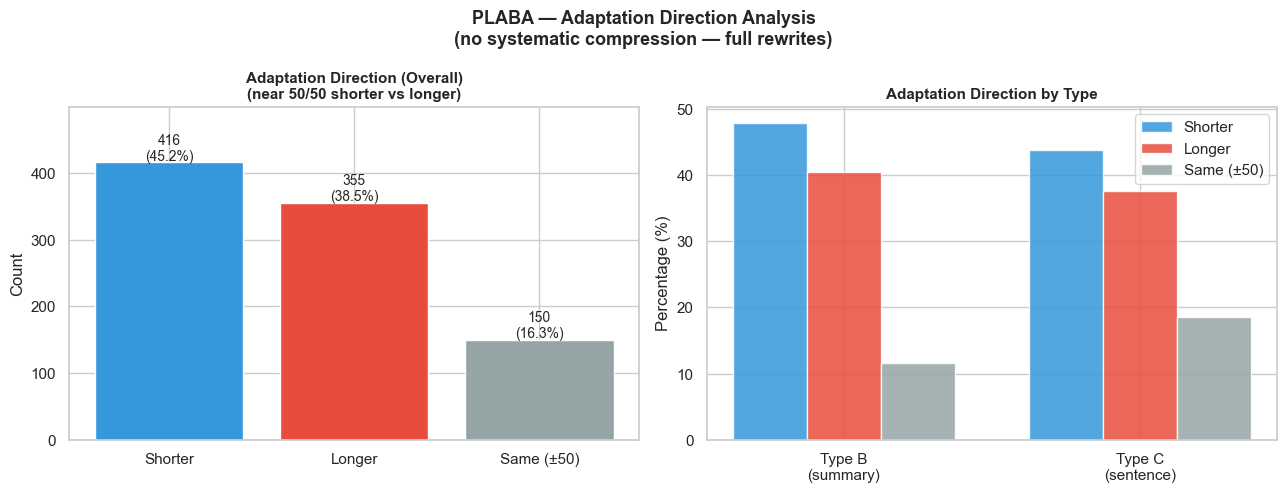

Fig 9b saved — plaba_adaptation_direction.png


In [12]:
diff = df['target_len'] - df['input_len']
direction = diff.apply(lambda x: 'Shorter' if x < -50 else ('Longer' if x > 50 else 'Same (±50)'))
dir_counts = direction.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_dir = {'Shorter': '#3498db', 'Longer': '#e74c3c', 'Same (±50)': '#95a5a6'}
bars = axes[0].bar(dir_counts.index, dir_counts.values,
                   color=[colors_dir.get(d,'#cccccc') for d in dir_counts.index], edgecolor='white')
for bar, val in zip(bars, dir_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)
axes[0].set_title('Adaptation Direction (Overall)\n(near 50/50 shorter vs longer)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].set_ylim(0, dir_counts.max()*1.2)

x = np.arange(2); width = 0.25
for i, (direc, color) in enumerate(colors_dir.items()):
    vals = []
    for qt in ['B','C']:
        subset = df[df['Question_Type']==qt]
        d = subset['target_len'] - subset['input_len']
        if direc == 'Shorter': v = (d < -50).sum()
        elif direc == 'Longer': v = (d > 50).sum()
        else: v = (d.abs() <= 50).sum()
        vals.append(v/len(subset)*100)
    axes[1].bar(x + i*width, vals, width, color=color, label=direc, edgecolor='white', alpha=0.85)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['Type B\n(summary)', 'Type C\n(sentence)'])
axes[1].set_title('Adaptation Direction by Type', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Percentage (%)'); axes[1].legend()

plt.suptitle('PLABA — Adaptation Direction Analysis\n(no systematic compression — full rewrites)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/plaba_adaptation_direction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 9b saved — plaba_adaptation_direction.png')

## 9c. Readability Scores — 2.2 Grade Level Reduction

FK: 14.9→12.6 (-2.2 grades). FRE: 24.6→40.7 (+16.1 points).
Plain language still graduate level — ORACLE must reduce further to FK=8 (8th grade).

Computing readability scores on full dataset...


Done — FK input=14.9 target=12.6


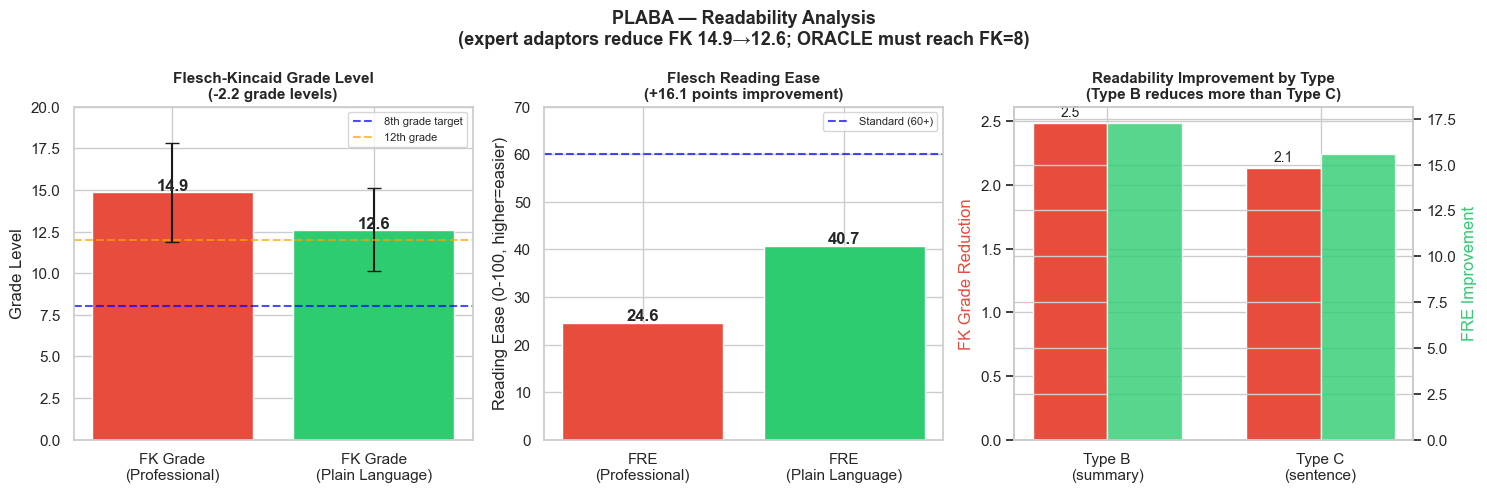

Fig 9c saved — plaba_readability.png


In [13]:
import textstat
print('Computing readability scores on full dataset...')
df['fk_input'] = df['input_text'].apply(textstat.flesch_kincaid_grade)
df['fk_target'] = df['target_text'].apply(textstat.flesch_kincaid_grade)
df['fre_input'] = df['input_text'].apply(textstat.flesch_reading_ease)
df['fre_target'] = df['target_text'].apply(textstat.flesch_reading_ease)
df['smog_input'] = df['input_text'].apply(textstat.smog_index)
df['smog_target'] = df['target_text'].apply(textstat.smog_index)
print(f'Done — FK input={df["fk_input"].mean():.1f} target={df["fk_target"].mean():.1f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# FK Grade Level
metrics = ['FK Grade\n(Professional)', 'FK Grade\n(Plain Language)']
fk_vals = [df['fk_input'].mean(), df['fk_target'].mean()]
fk_stds = [df['fk_input'].std(), df['fk_target'].std()]
bars = axes[0].bar(metrics, fk_vals, color=['#e74c3c','#2ecc71'], edgecolor='white',
                   yerr=fk_stds, capsize=5)
for bar, val in zip(bars, fk_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')
axes[0].axhline(8, color='blue', linestyle='--', alpha=0.7, label='8th grade target')
axes[0].axhline(12, color='orange', linestyle='--', alpha=0.7, label='12th grade')
axes[0].set_title(f'Flesch-Kincaid Grade Level\n(-{df["fk_input"].mean()-df["fk_target"].mean():.1f} grade levels)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Grade Level'); axes[0].legend(fontsize=8); axes[0].set_ylim(0, 20)

# Flesch Reading Ease
fre_vals = [df['fre_input'].mean(), df['fre_target'].mean()]
bars2 = axes[1].bar(['FRE\n(Professional)', 'FRE\n(Plain Language)'],
                    fre_vals, color=['#e74c3c','#2ecc71'], edgecolor='white')
for bar, val in zip(bars2, fre_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')
axes[1].axhline(60, color='blue', linestyle='--', alpha=0.7, label='Standard (60+)')
axes[1].set_title(f'Flesch Reading Ease\n(+{df["fre_target"].mean()-df["fre_input"].mean():.1f} points improvement)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Reading Ease (0-100, higher=easier)'); axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 70)

# By Type
types = ['B', 'C']
fk_red_by_type = [df[df['Question_Type']==qt]['fk_input'].mean() - df[df['Question_Type']==qt]['fk_target'].mean() for qt in types]
fre_imp_by_type = [df[df['Question_Type']==qt]['fre_target'].mean() - df[df['Question_Type']==qt]['fre_input'].mean() for qt in types]
x = np.arange(2); width = 0.35
axes[2].bar(x-width/2, fk_red_by_type, width, color='#e74c3c', label='FK reduction (grades)', edgecolor='white')
ax2 = axes[2].twinx()
ax2.bar(x+width/2, fre_imp_by_type, width, color='#2ecc71', label='FRE improvement (points)', edgecolor='white', alpha=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(['Type B\n(summary)', 'Type C\n(sentence)'])
axes[2].set_ylabel('FK Grade Reduction', color='#e74c3c')
ax2.set_ylabel('FRE Improvement', color='#2ecc71')
axes[2].set_title('Readability Improvement by Type\n(Type B reduces more than Type C)', fontsize=11, fontweight='bold')
for bar, val in zip(axes[2].patches, fk_red_by_type):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{val:.1f}', ha='center', fontsize=10)

plt.suptitle('PLABA — Readability Analysis\n(expert adaptors reduce FK 14.9→12.6; ORACLE must reach FK=8)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/plaba_readability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 9c saved — plaba_readability.png')

## 10. Key Observations

**Total: 921 instances** — 750 unique abstracts across 75 health topics
**Type C (68.1%):** sentence-level adaptation — preserves structure, simplifies vocabulary
**Type B (31.9%):** summary-level adaptation — restructures and reorganizes content
**Compression ratio ~1.0** — plain language = full-length rewrite, NOT a summary
**Word ratio = 1.064** — plain language uses MORE words (shorter words, more of them)
**53.4% adaptations shorter, 46.5% longer** — near even split, confirms no systematic compression
**Mean 12.3 records per topic** — multiple adaptation versions per abstract for diverse training
**No missing values** — PLABA is a clean gold standard dataset
**ORACLE role:** Only dataset with paired professional + plain language at sentence level — gold standard for Stage 3 generation evaluation